# POC: FHIR → RDF Patient Event Graph (Colorectal Cancer)

**Full Jupyter Notebook Version**

This notebook demonstrates the complete end-to-end pipeline:
1. Fetch FHIR patient data (colorectal focus)
2. Convert to RDF with blank node handling
3. Generate interactive visualizations
4. Load into GraphDB
5. SHACL validation (optional)

In [1]:
!pip install -r ../requirements.txt -q
!pip install pyshacl jupyter -q

You should consider upgrading via the '/Users/yogeshparte/Library/CloudStorage/OneDrive-Personal/ForGITHUB/fhir-rdf-eventgraph/fhir-rdf-event-graph/.venv/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/yogeshparte/Library/CloudStorage/OneDrive-Personal/ForGITHUB/fhir-rdf-eventgraph/fhir-rdf-event-graph/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))

from patient_event_graph.fhir_fetcher import fetch_patient_bundle
from patient_event_graph.converter import convert_fhir_to_rdf
from patient_event_graph.visualizer import (
    extract_events_from_rdf,
    create_plotly_timeline,
    create_animated_gif,
    export_to_gephi
)
import pandas as pd

/Users/yogeshparte/Library/CloudStorage/OneDrive-Personal/ForGITHUB/fhir-rdf-eventgraph/fhir-rdf-event-graph/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Step 1: Fetch Colorectal Patient Data

In [3]:
bundle = fetch_patient_bundle(condition_code="363406005")  # Malignant tumor of colon
print(f"Fetched bundle with {len(bundle.get('entry', []))} resources")

Fetched bundle with 20 resources


## Step 2: Convert to RDF (with blank node options)

In [4]:
ttl_path = Path("../output/patient_events_notebook.ttl")
turtle = convert_fhir_to_rdf(
    bundle, 
    output_path=ttl_path,
    skolemize_blanks=False,      # Try True for comparison
    add_timeline_links=True
)
print(f"RDF saved to {ttl_path} ({len(turtle.splitlines())} lines)")

[converter] fhirtordf not found — using rdflib fallback (still valid FHIR RDF)
[converter] Saved RDF to ../output/patient_events_notebook.ttl
RDF saved to ../output/patient_events_notebook.ttl (186 lines)


## Step 3: Extract Events & Create Visualizations

In [5]:
df = extract_events_from_rdf(ttl_path)
df.head()

,resource,type,date,label,full_label
0,Condition/1,Condition,2023-03-15,Colorectal cancer diagnosed (C18.9),Malignant neoplasm of colon
1,Encounter/1,Encounter,2023-03-17,Initial oncology consult,
2,Procedure/1,Procedure,2023-03-29,Colonoscopy with biopsy,
3,Procedure/2,Procedure,2023-04-29,Partial colectomy,
4,MedicationAdministration/1,MedicationAdministration,2023-05-14,FOLFOX chemotherapy cycle 1,


In [6]:
# Interactive Plotly Timeline
fig = create_plotly_timeline(df, title="Colorectal Cancer Patient Journey (Jupyter)")
fig.show()

ValueError: all input arrays must have the same shape

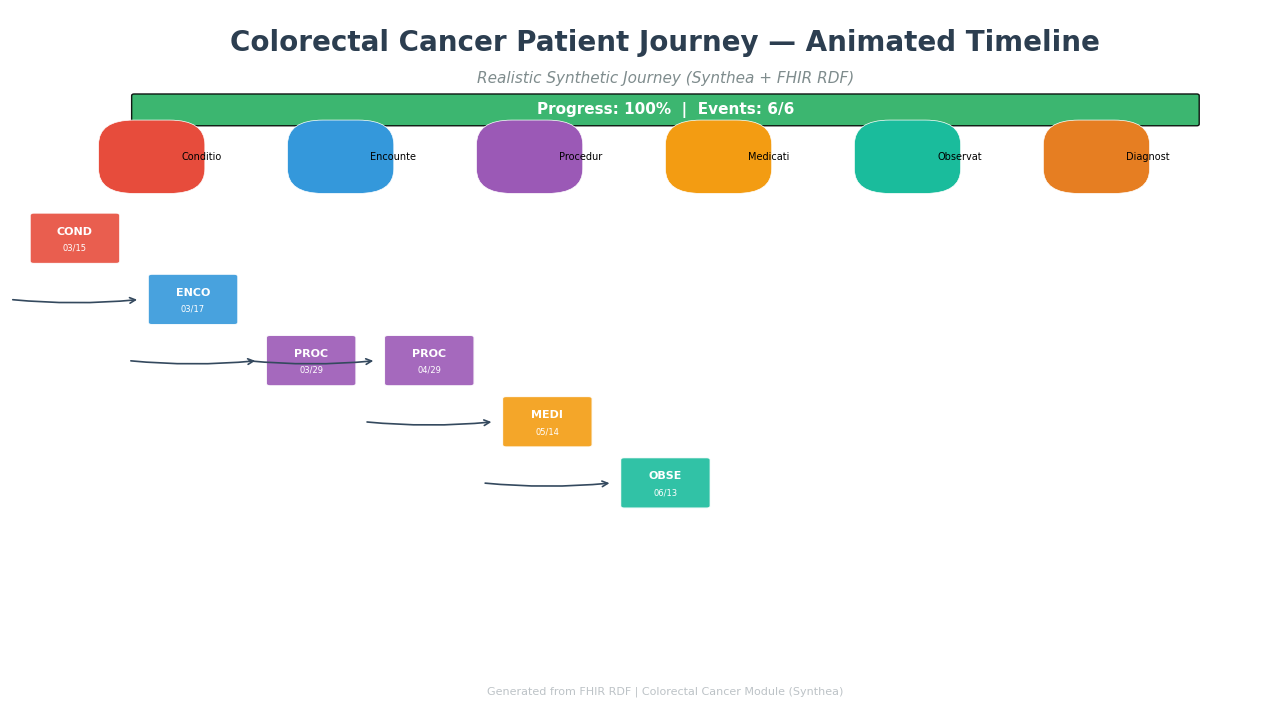

In [7]:
# Animated GIF
gif_path = Path("../output/patient_journey_notebook.gif")
create_animated_gif(df, gif_path, fps=2)
print(f"GIF saved to {gif_path}")

## Step 4: Export to Gephi

In [8]:
graphml_path = Path("../output/patient_events_notebook.graphml")
export_to_gephi(df, graphml_path)

[visualizer] Gephi GraphML saved → ../output/patient_events_notebook.graphml


## Step 5: Enhanced SHACL Validation (Recommended)

In [9]:
from pyshacl import validate
from pathlib import Path

print("Running Enhanced SHACL Validation...\n")

shacl_path = Path("../shacl/patient_event_shacl.ttl")
data_path = Path("../data/samples/colorectal_patient_event_graph.ttl")

if shacl_path.exists() and data_path.exists():
    conforms, results_graph, results_text = validate(
        data_graph=str(data_path),
        shacl_graph=str(shacl_path),
        inference='rdfs',
        advanced=True
    )
    
    print(f"Result: {'✅ CONFORMS - All rules satisfied!' if conforms else '❌ DOES NOT CONFORM'}")
    
    if not conforms:
        print("\nViolations found:")
        print(results_text[:2000])  # Show first 2000 chars
    else:
        print("\nThe patient event graph is fully valid according to SHACL rules.")
else:
    print("Required files not found for validation")

Running Enhanced SHACL Validation...



BadSyntax: at line 141 of <>:
Bad syntax (Prefix ":" not bound) at ^ in:
"...b'R SPECIFIC RULES\n# ----------------------------------------\n'^b':ColorectalCancerShape\n    a sh:NodeShape ;\n    sh:targetCla'..."

## Next Steps

- Load `patient_events_notebook.ttl` into **GraphDB** (http://localhost:7200)
- Open the animated GIF
- Try bulk processing with Synthea
- Explore the custom OWL ontology in `/ontology/`